# Decision Tree

- A döntési fa egy osztályozási modell, amely a bemeneti vektor elemei alapján hozza a döntését
- Egy fa struktúrát használ, ahol minden belső csomópont egy vizsgálat (decision node), és minden levél egy döntés, milyen osztályhoz tartozik az adat (leaf)
- A döntés során sorozatos teszteket végez az attribútumokon (de pontosan egyen)
- A gyökértől kiindulva a megfelelő ág mentén haladunk, amíg egy levélelemet el nem érünk
- A logikai döntési fa diszjunktív normálformában is kifejezhető (egy út gyökértől a levélig ÉS kapcsolatok, az azonos osztályhoz tartozó levelek VAGY)

### Split? Hogyan?

- "Leghatékonyabb" split kiválasztása hogyan történjen?
    - __Entrópia__ (egy adott node-ban):
\begin{equation}
E=\sum_{ class_i } -p_i*log_{2}(p_i) 
\end{equation}
 $p_i$: hány példány van $i$ osztályból osztva az összes példánnyal egy adott node-ban,
 E=1 maximális káosz, E=0 homogén (minden példány azonos osztályú)
    - __Gini-index__ (impurity, egy adott node-ban):
\begin{equation}
G=1 - \sum_{ class_i } p_i^2
\end{equation}
G=0 homogén, G->1 káosz sok class esetén

    - (__Variancia__ (regressziónál): ...)
- Célunk a káosz (chaos=entrópia|gini|variancia) csökkentése a gyerek csomópontokban (aggregáltan, súlyozottan):
\begin{equation}
\sum_{ class_i } w_i * E(child_i)
\end{equation}
$w_i$: a $child_i$ gyerek node-ban lévő példányok száma osztva a szülő összes példányával
- azt a változót (összes feature közül) és azt a küszöbértéket (a feature unique értékei közül) választjuk, ahol ez __minimális__ (legjobb fa keresése NP-teljes optimalizálási feladat)


## Paraméterek

- __criterion__: split választásának kritériuma: "gini" (alapértelmezett), "entropy"
- __max_features__: splitnél figyelembe vett jellemzők maximuma (random választ ennyit)
- __max_depth__: a fa maximális mélysége (segít megelőzni a túlilleszkedést) => leaf node-ok vegyesek lehetnek, többség dönti el a prediktált class-t
- __min_samples_split__: minimum mintaszám egy belső csomópont szétválasztásához (ha ez alá megy, már nem split-elődik, hanem leaf node lesz; ill. ha 0.1, akkor a min_samples_split=összes adat 10%-a; túlillesztés ellen)
- __min_samples_leaf__: minimum mintaszám egy levélcsomópontban (ha egy split ezt nem teljesíti, az nem opció)

### ...néhány output
- __predict(X)__: prediktált osztály(ok)
- __predict_proba(X)__: visszaadja a prediktált osztályhoz tartozó valószínűségeket (az adott leaf node-ban a class példányok arányát)
- __feature_importances___: megmutatja, hogy mely jellemzők mennyiben járultak hozzá a döntésekhez (hány decision node-ban volt ez a feature használva és mennyire csökkent az entrópia a gyerekeiben)
- __plot_tree()__, __export_text()__: a döntési fa vizuális vagy szöveges megjelenítése

Apple


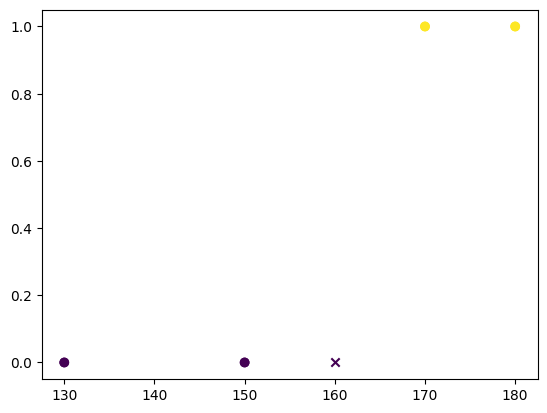

In [15]:
import numpy as np

# feature1: súly (g), feature2: mintázat (0: sima, 1: rücskös)
X = np.array([[150, 0], [130, 0], [180, 1], [170, 1]]) 
# 0: alma, 1: narancs
y = np.array([0, 0, 1, 1]) 

import matplotlib.pyplot as plt
plt.scatter(X[:,0],X[:,1],c=y)

# ! pip install scikit-learn
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X, y)

new_fruit = np.array([160, 0]) # egy új adat
prediction = model.predict(new_fruit.reshape(1, 2)) 
print("Apple" if prediction[0] == 0 else "Orange")

plt.scatter(X[:,0],X[:,1],c=y)
plt.scatter(new_fruit[0],new_fruit[1],c=prediction, marker="x")

|--- Weight <= 160.00
|   |--- weights: [2.00, 0.00] class: Apple
|--- Weight >  160.00
|   |--- weights: [0.00, 2.00] class: Orange



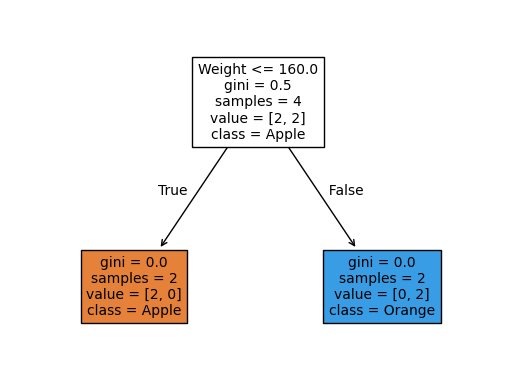

In [58]:
import matplotlib.pyplot as plt
from sklearn import tree

tree.plot_tree(model, feature_names=["Weight", "Texture"], class_names=["Apple", "Orange"], filled=True, fontsize=10)
print(tree.export_text(model, feature_names=["Weight", "Texture"], class_names=["Apple", "Orange"], show_weights=True))

# Note: nem mindig ugyanaz az eredmény (random on Multiple Splits with the Same Gain)

### Breast Cancer Dataset

In [16]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X, y = data.data, data.target

import pandas as pd
df = pd.DataFrame(data.data, columns=data.feature_names) 
print("Minták (samples) száma:", df.shape[0])
print("Jellemzők (features) száma:", df.shape[1])

df["target"] = data.target # a target külön van: 1: benign (jóindulatú), 0: malignant (rosszindulatú)
print("Célváltozó:", dict(enumerate(data.target_names))) # malignant

df.head(3)

Minták (samples) száma: 569
Jellemzők (features) száma: 30
Célváltozó: {0: np.str_('malignant'), 1: np.str_('benign')}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0


In [7]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report

model = DecisionTreeClassifier() # default beállítások, korlátlan
model.fit(X, y)
y_pred = model.predict(X)

print(classification_report(y, y_pred, target_names=data.target_names)) # 100%

              precision    recall  f1-score   support

   malignant       1.00      1.00      1.00       212
      benign       1.00      1.00      1.00       357

    accuracy                           1.00       569
   macro avg       1.00      1.00      1.00       569
weighted avg       1.00      1.00      1.00       569



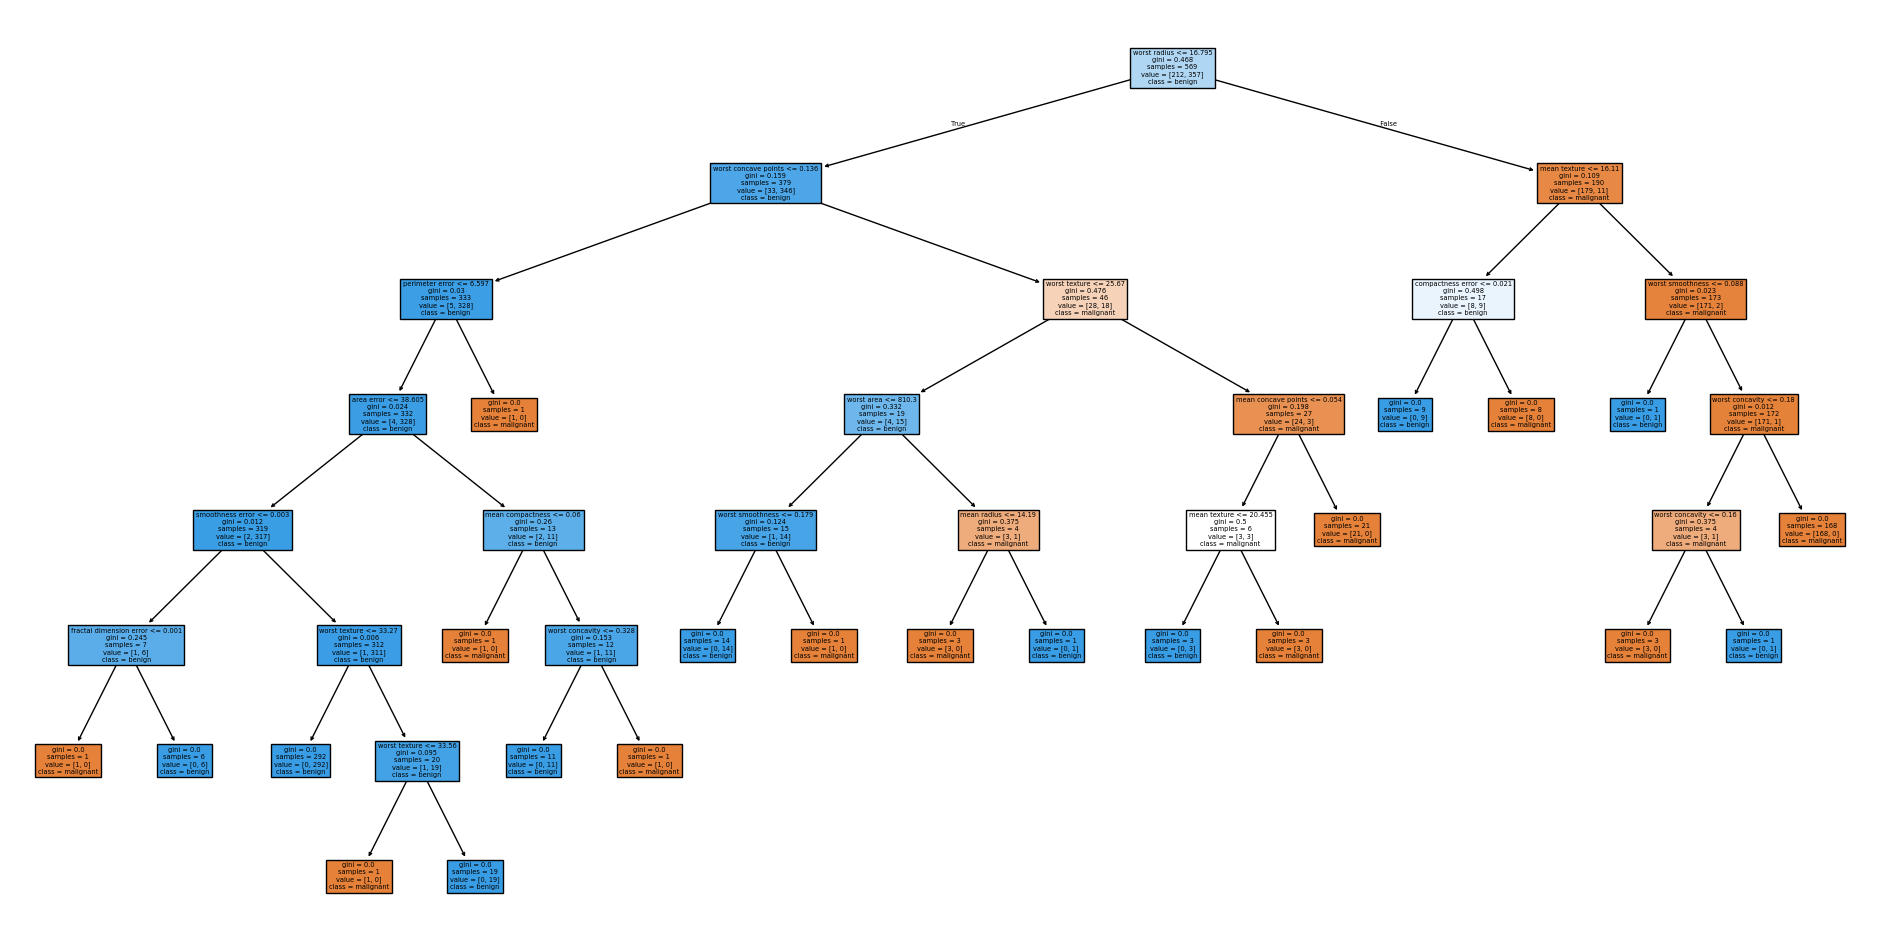

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(24, 12))
plot_tree(model, feature_names=data.feature_names, class_names=data.target_names, filled=True)
plt.show()



[0.         0.04892877 0.         0.         0.         0.
 0.         0.00877112 0.         0.         0.         0.
 0.         0.00936121 0.00100384 0.03184137 0.         0.00563858
 0.         0.         0.69559352 0.0460766  0.         0.01672448
 0.01440488 0.00689159 0.00183582 0.11292823 0.         0.        ]


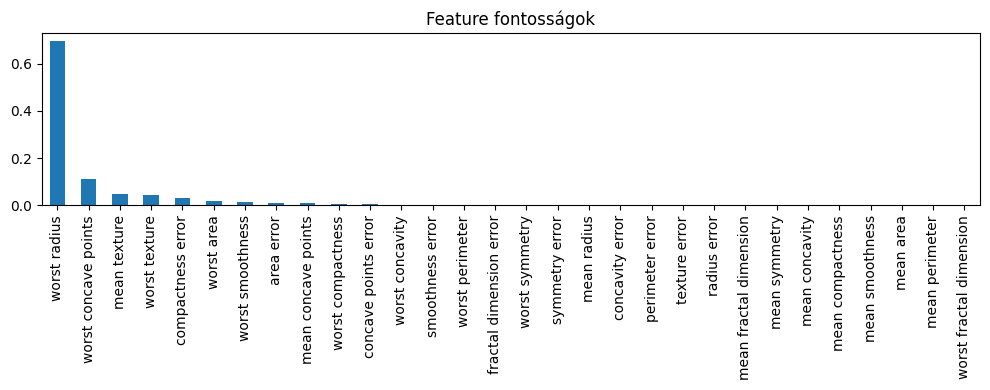

In [4]:
print(model.feature_importances_) # melyik feature, mennyivel járult hozzá a döntésekhez (impurity csökkenés), normalizálva

importances = pd.Series(model.feature_importances_, index=data.feature_names)
importances.sort_values(ascending=False).plot(kind="bar", figsize=(10, 4), title="Feature fontosságok")
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

   malignant       0.91      0.94      0.92       212
      benign       0.96      0.94      0.95       357

    accuracy                           0.94       569
   macro avg       0.94      0.94      0.94       569
weighted avg       0.94      0.94      0.94       569



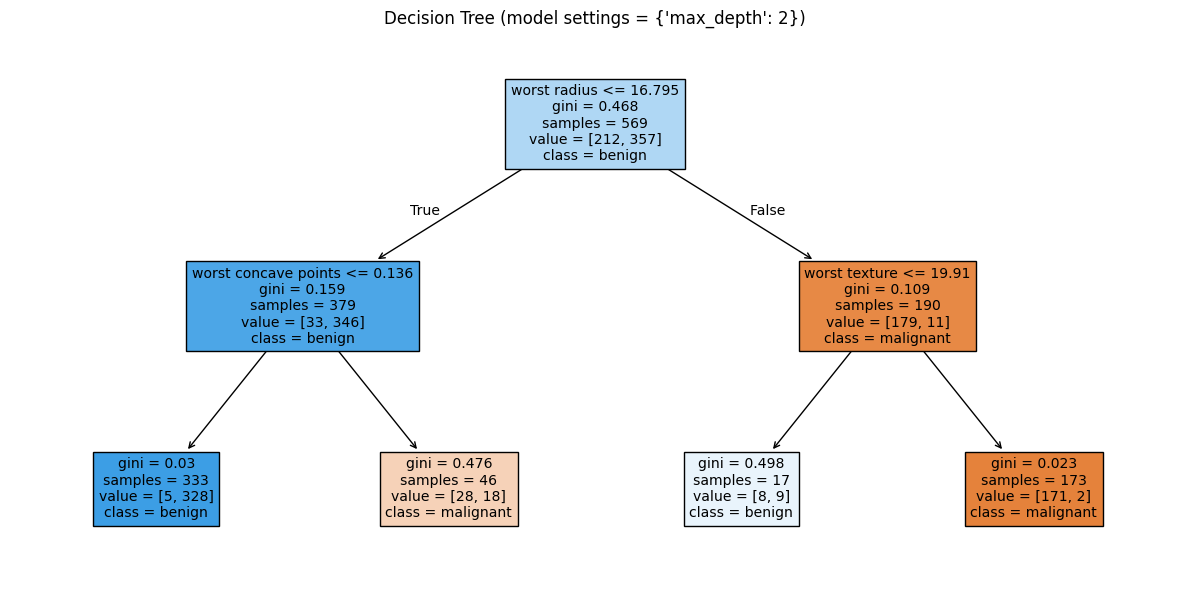

              precision    recall  f1-score   support

   malignant       0.91      0.94      0.93       212
      benign       0.97      0.95      0.96       357

    accuracy                           0.95       569
   macro avg       0.94      0.95      0.94       569
weighted avg       0.95      0.95      0.95       569



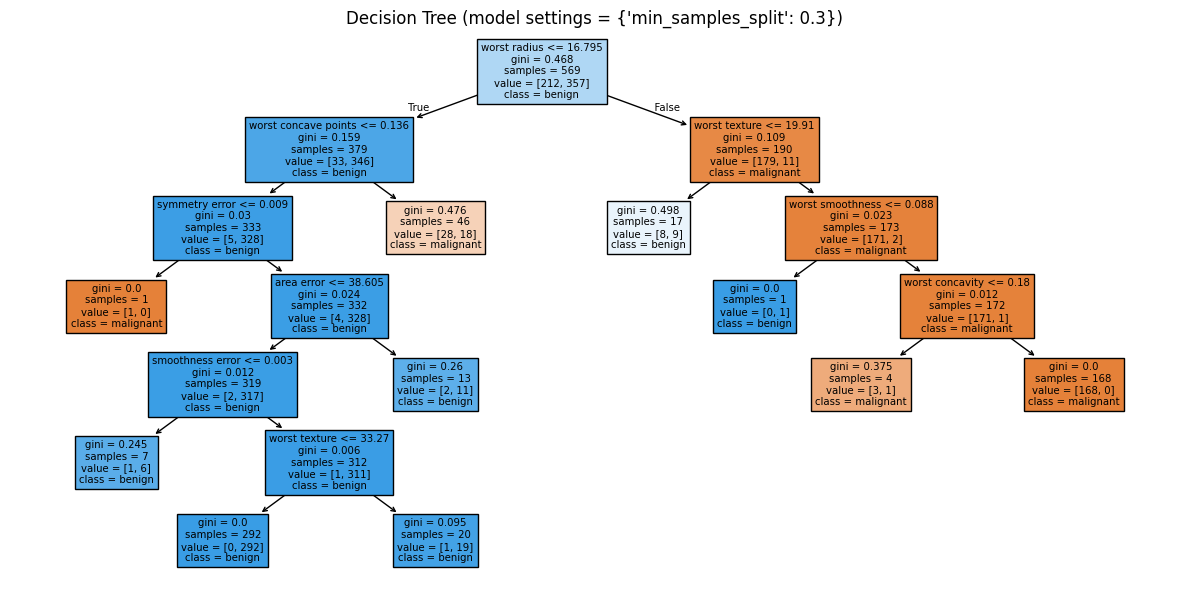

              precision    recall  f1-score   support

   malignant       0.97      0.92      0.95       212
      benign       0.95      0.99      0.97       357

    accuracy                           0.96       569
   macro avg       0.96      0.95      0.96       569
weighted avg       0.96      0.96      0.96       569



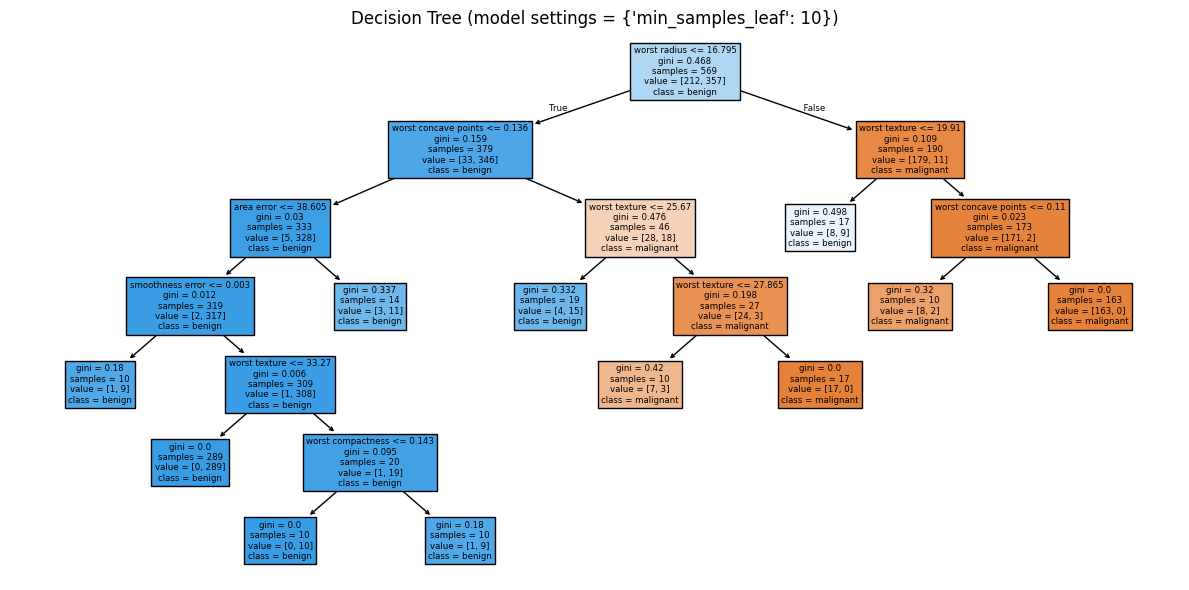

In [19]:
settings = [
    {"max_depth": 2},
    {"min_samples_split": 0.3}, # 0.3 * 569 (osszes adat) = 170
    {"min_samples_leaf": 10},
]

# Train and evaluate models with different settings
for i, params in enumerate(settings):
    clf = DecisionTreeClassifier(**params)
    clf.fit(X, y)
    y_pred = clf.predict(X)
    print(classification_report(y, y_pred, target_names=data.target_names))

    plt.figure(figsize=(12, 6))
    plot_tree(clf, feature_names=data.feature_names, class_names=data.target_names, filled=True)
    plt.title(f"Decision Tree (model settings = {settings[i]})")
    plt.tight_layout()
    plt.show()

# Random Forest

- a döntési fák együttes tanulásán alapuló modell
- több független döntési fát képezünk és azok szavazással döntenek az osztályozásról
- Működése:
    - bagging: minden egyes döntési fa más-más adathalmazból tanul (az eredeti halmazból választva max_samples darabot (default: összes adat), random, ismétlések lehetnek)
    - véletlenszerű attribútum választás: minden egyes splitnél csak az attribútumok egy véletlenszerű része vizsgálható
    - többségi szavazás: az egyes fák szavazata alapján történik a végső döntés

### Paraméterek
- __n_estimators__: a döntési fák száma az erdőben (default: 100)
- __bootstrap__: bootstrapping engedélyezése (adatok random mintavételezése), default: True
- __max_features__: splitnél figyelembe vett jellemzők maximuma (default: sqrt(#features))

### Teljesítménymérés
__oob_score___: out-of-bag becsült pontosság (amennyiben az egyes adathalmazok random részei a teljes adathalmaznak (max_samples < adathalmaz méret, bootstrap=True), a kimaradt adatok használhatóak tesztelésre)


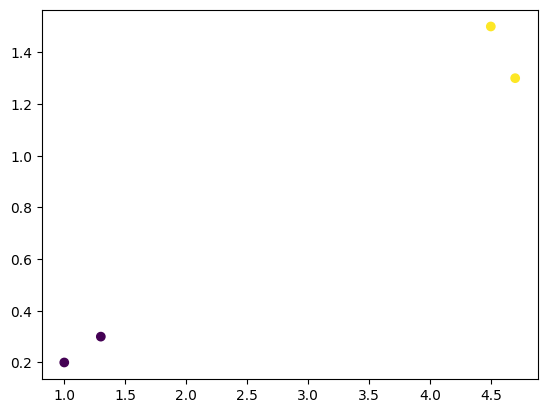

In [62]:
import numpy as np

X = np.array([[1.0, 0.2], [1.3, 0.3], [4.5, 1.5], [4.7, 1.3]])
y = np.array([0, 0, 1, 1])

import matplotlib.pyplot as plt
plt.scatter(X[:,0],X[:,1],c=y)


0


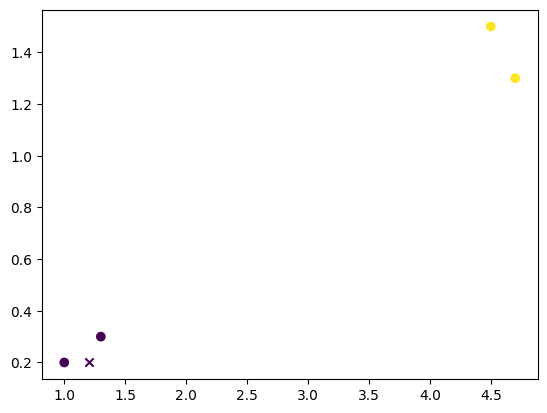

In [63]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=10)
clf.fit(X, y)

sample = np.array([[1.2, 0.2]])
prediction = clf.predict(sample)

print(prediction[0])
plt.scatter(X[:,0],X[:,1],c=y)
plt.scatter(sample[:,0],sample[:,1],c=prediction, marker="x")


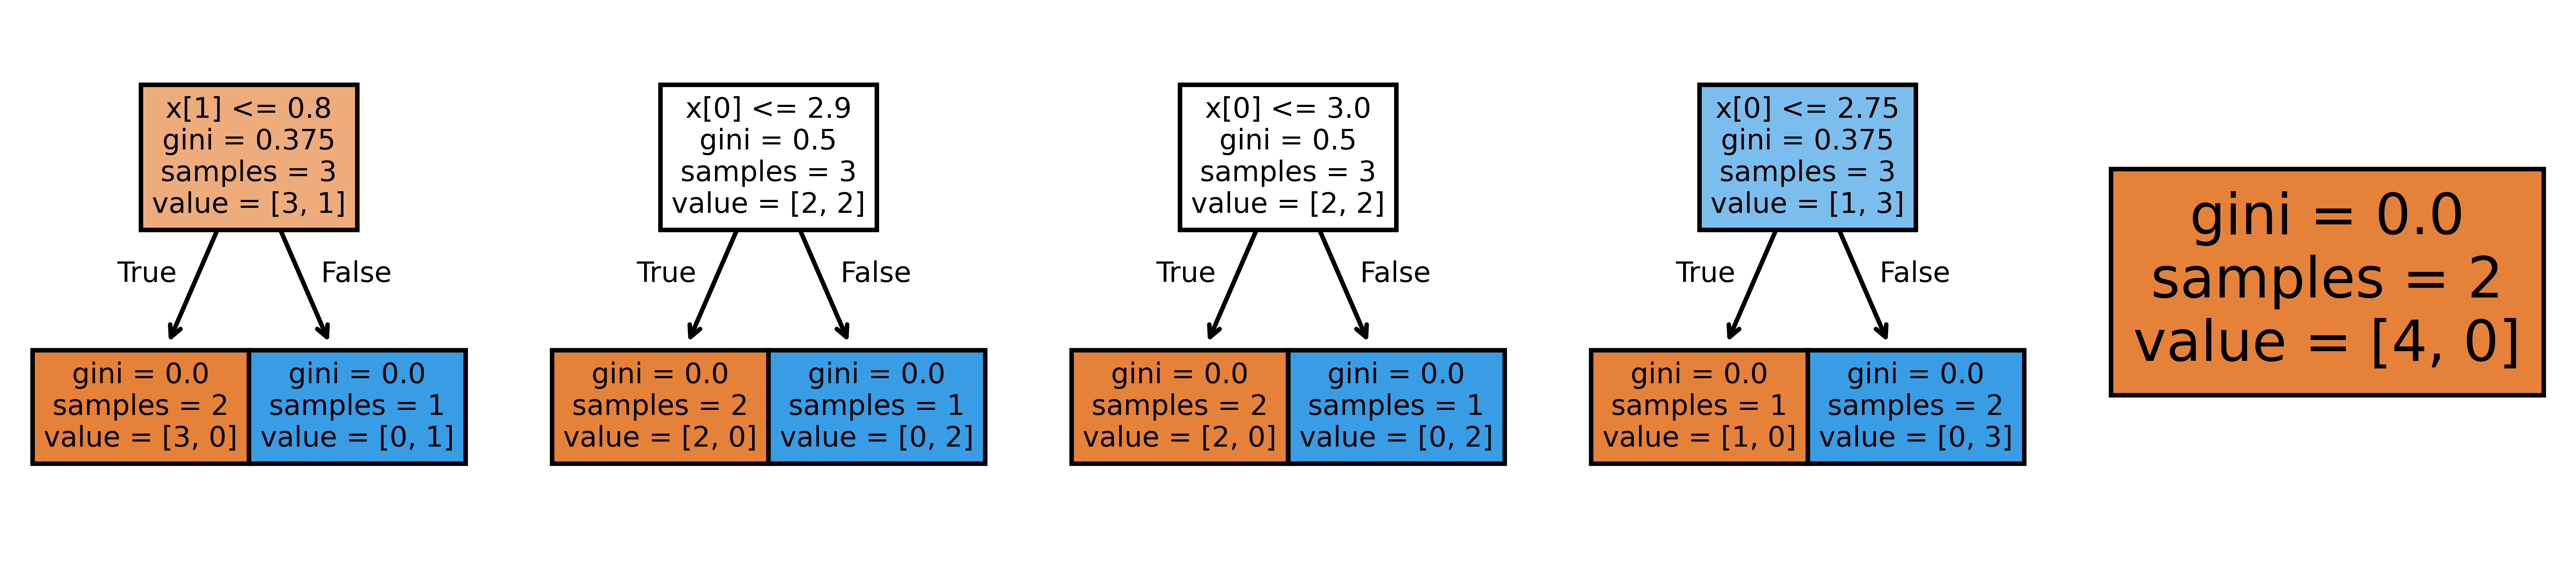

In [64]:
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(10,2), dpi=900)
for index in range(0, 5):
    tree.plot_tree(clf.estimators_[index], filled=True, ax=axes[index])
# samples (3) != values ([3,1]), samples: egyedi adatok, de a bootstrap mintavételezés duplikációkat okozhat

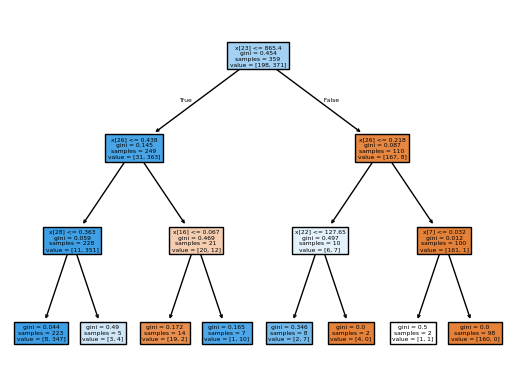

In [65]:
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier, plot_tree

data = load_breast_cancer()
X, y = data.data, data.target

clf = RandomForestClassifier(n_estimators=10, max_depth=3)
clf.fit(X, y)

tree.plot_tree(clf.estimators_[0], filled=True) # az egyik fa
plt.show()

### Feladat
- Breast cancer dataset
- Teszt adathalmaz leválasztása
- Döntési fa (maximális mélység: 4) és
- Véletlen erdő (50 fa, maximális mélység: 4) klasszifikáció alkalmazása
- Eredmények, metrikák összehasonlítása a teszt adathalmazon
- A legfontosabb feature-ök megjelenítése

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y # az adatok 20%-a teszt, 80%-a tanító, random_state: ugyanaz a véletlenszerű szétosztás minden futtatáskor, stratify: az osztályok arányát megtartja a train/test szétosztásban
)

# dontesi fa

from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(max_depth=4)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=data.target_names))
print(model.feature_importances_)

# random forest

from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators=50, max_depth=4)
rfc.fit(X, y)
rfc_y_pred = rfc.predict(X_test)
print(classification_report(y_test, rfc_y_pred, target_names=data.target_names))
print(rfc.feature_importances_)

              precision    recall  f1-score   support

   malignant       0.91      0.93      0.92        42
      benign       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114

[0.         0.01184648 0.         0.         0.         0.
 0.         0.01332729 0.         0.         0.         0.04578469
 0.         0.00315729 0.         0.         0.         0.
 0.         0.         0.73354757 0.03231926 0.         0.
 0.         0.         0.01716116 0.12202752 0.01128236 0.00954637]
              precision    recall  f1-score   support

   malignant       1.00      0.93      0.96        42
      benign       0.96      1.00      0.98        72

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

[0.00653307 0.01410722 0.0247284  